In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [3, 2, 4, 1, 0, 5]])

data = pd.read_csv("latency.csv")
data["Speedup"] = 0

models = set(data["Model"])
passes = set(data["Pass"])
frameworks = set(data["Framework"])
base_framework = "Nabla (Recompute)"

/tmp/ipykernel_1839910/81381859.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
for model in models:
    for pas in passes:
        base = data.loc[
            (data["Model"] == model) & 
            (data["Pass"] == pas) & 
            (data["Framework"] == base_framework), 
            "Time"
        ].item()
        for framework in frameworks:
            time = data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Time"
            ].item()
            data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Speedup"
            ] = base / time
            
gradient_data = data[data["Pass"] == "Gradient"]
total_data = data[data["Pass"] == "Total"]

/tmp/ipykernel_1839910/573059101.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.7173122734334542' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44


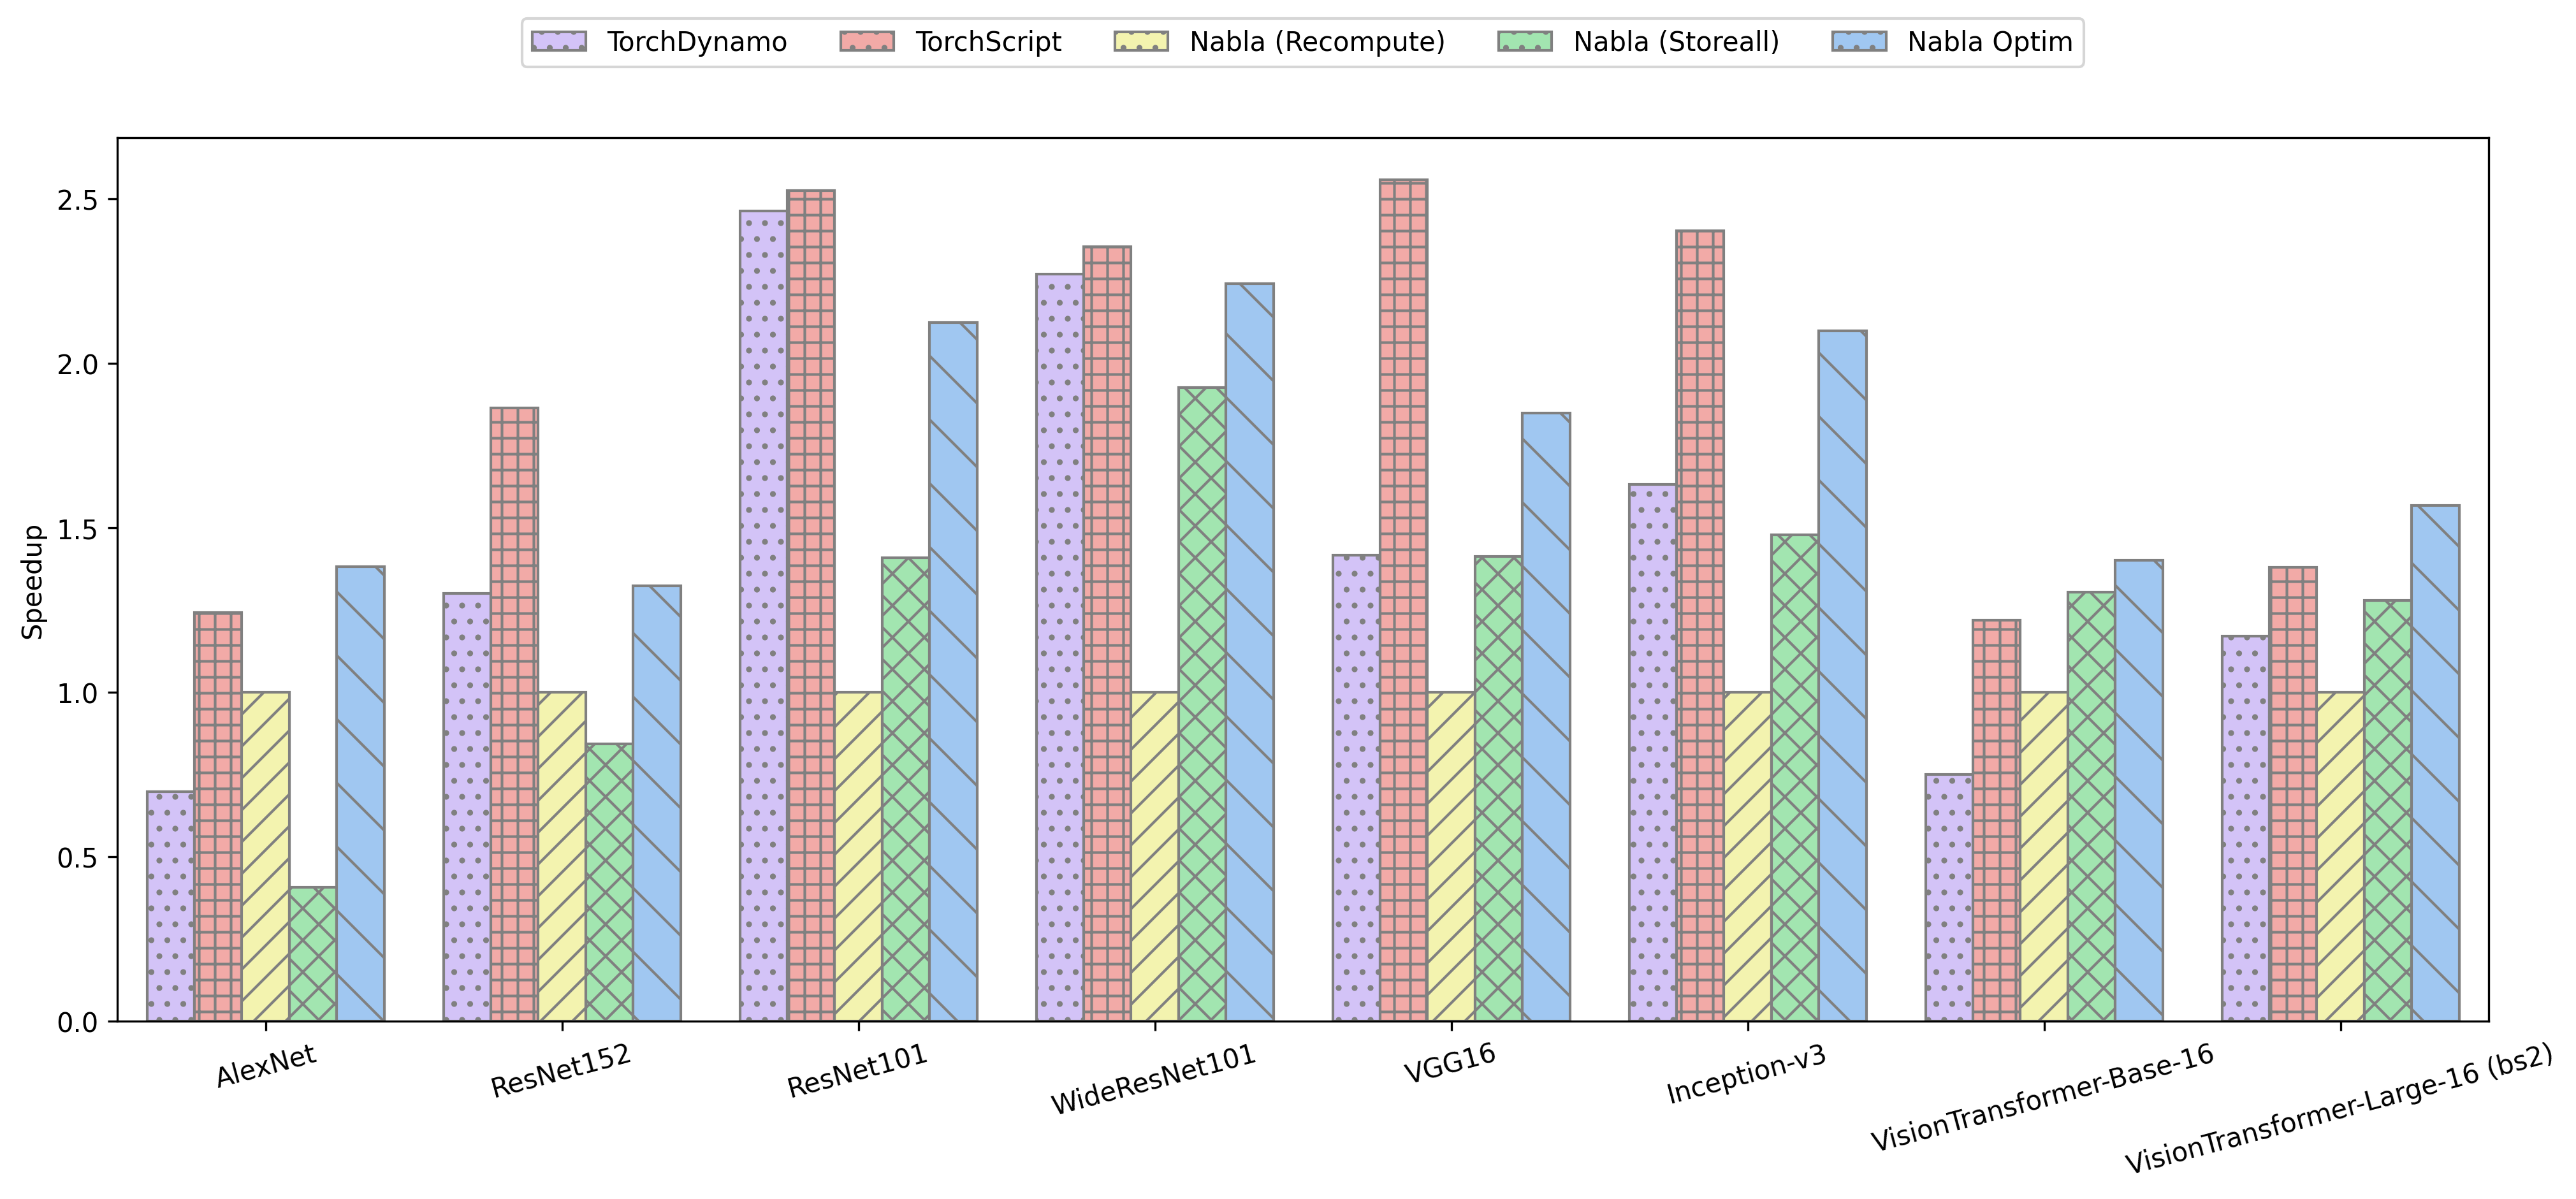

In [3]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["++", "//", "xx", "\\", ".."]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(gradient_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("gray")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15))

# plt.savefig("gradient.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_facecolor'

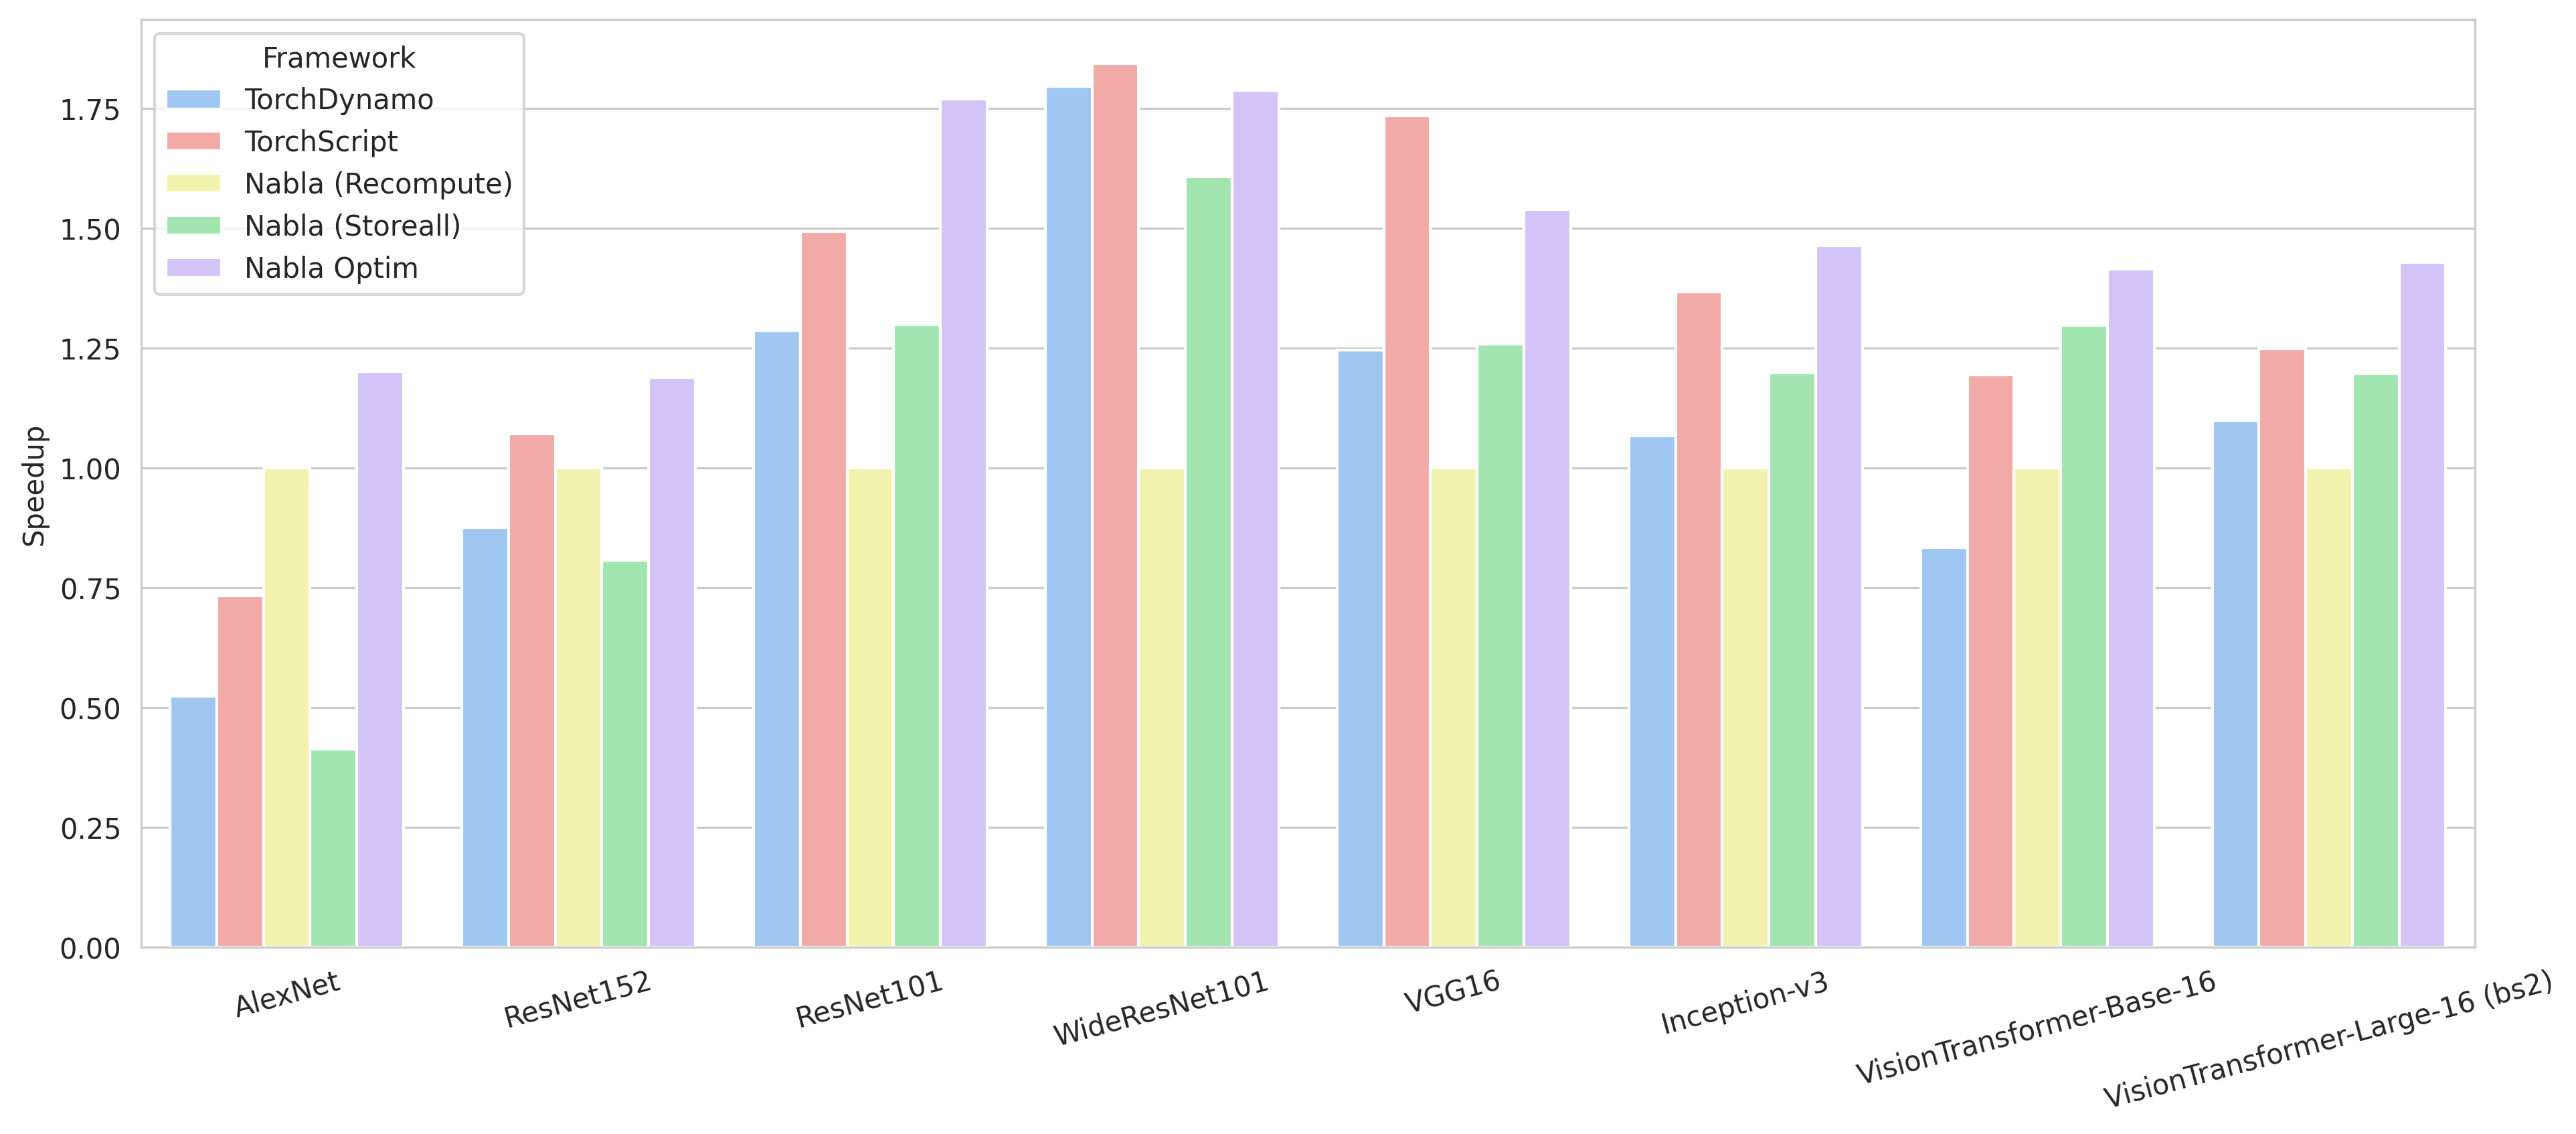

In [31]:
plt.rcParams["figure.figsize"] = (len(models) * 3, 6)

hatches = ["++", "//", "xx", "\\", ".."]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(total_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15)
plt.xlabel(None)


for i, bar in enumerate(barplot.patches):
    bar.set_hatch(hatches[i // len(models) -1])
    bar.set_edgecolor("black")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15))

plt.savefig("total.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

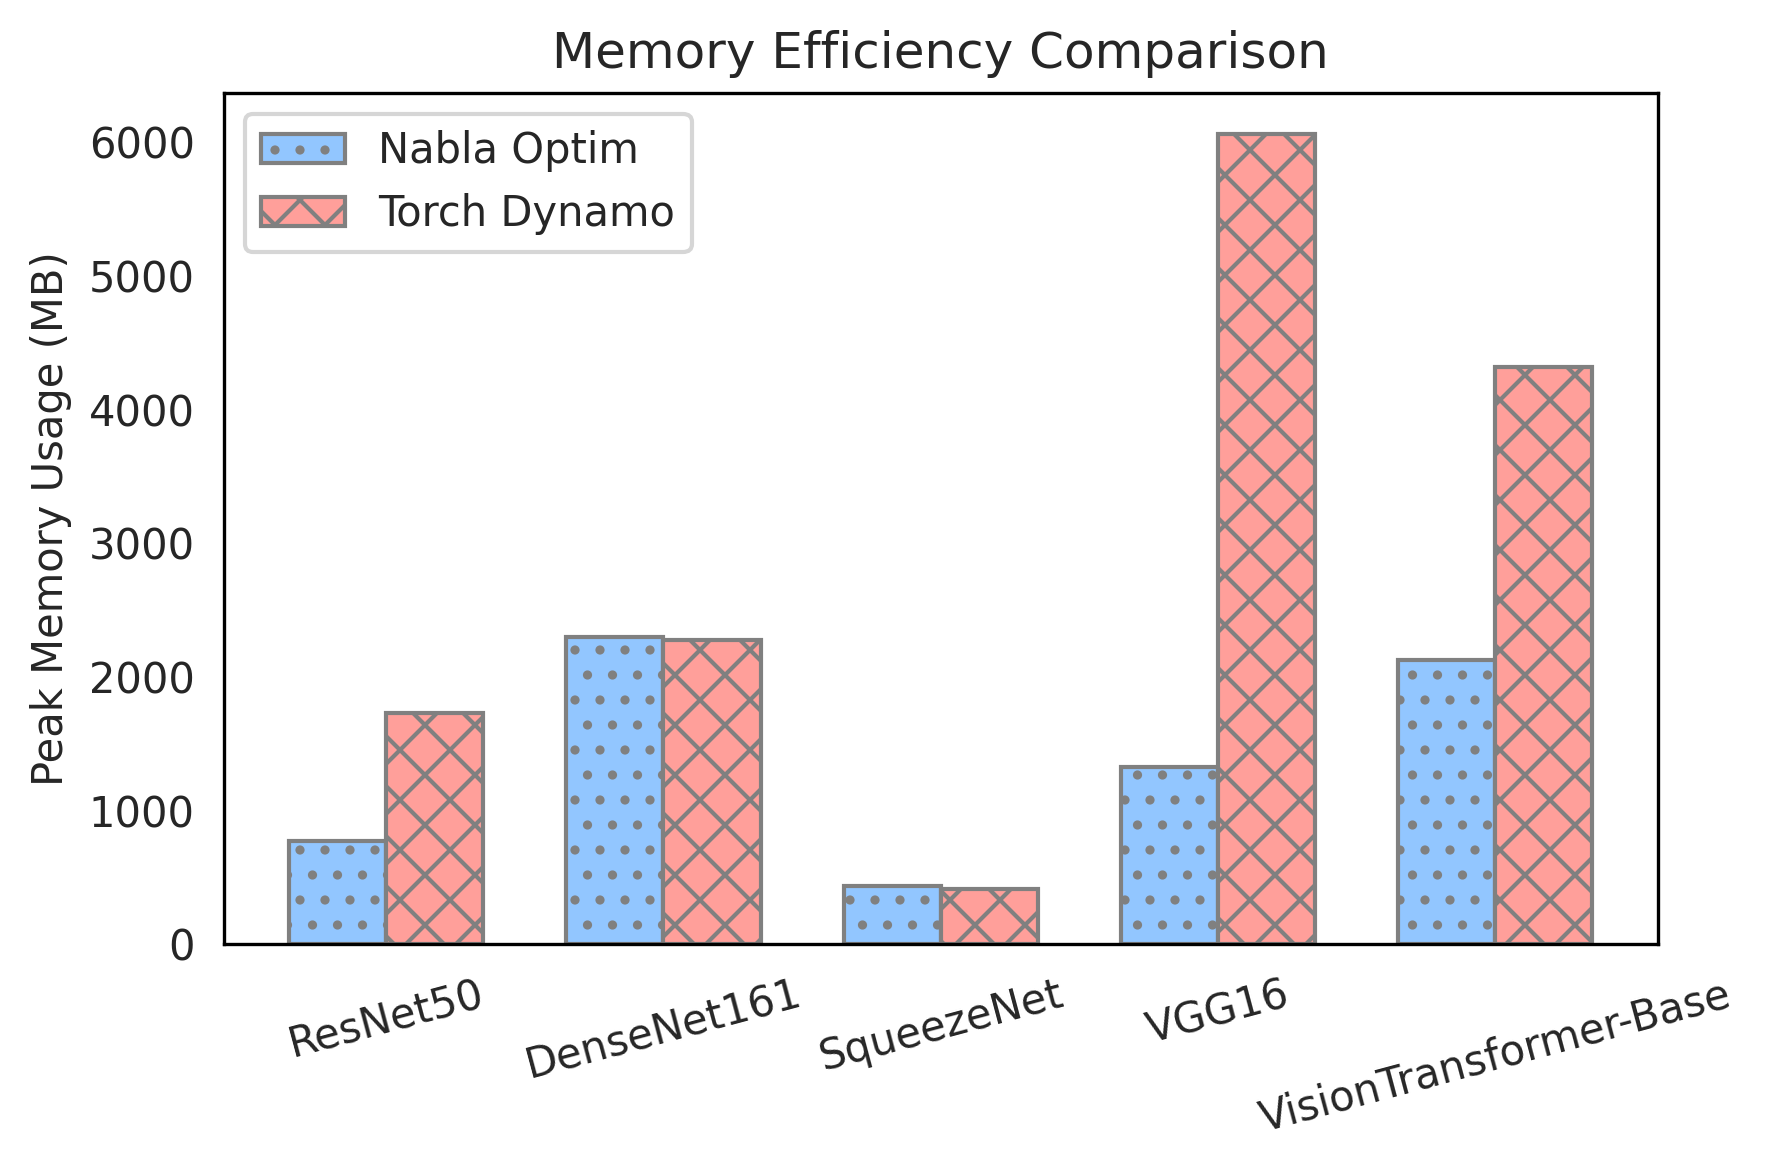

In [30]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 1, 3, 5]])

# Model names
models = ['ResNet50', 'DenseNet161', 'SqueezeNet', 'VGG16', 'VisionTransformer-Base']

# Defining the data
models = ['ResNet50', 'DenseNet161', 'SqueezeNet', 'VGG16', 'VisionTransformer-Base']
nabla_optim_scores = [771.5, 2303.5, 438.9, 1326.3, 2131.1]
torch_dynamo_scores = [1731.5, 2275.8, 416.2, 6066.6, 4323.2]

# Setting the positions and width for the bars
positions = np.arange(len(models))
bar_width = 0.35

# Creating the plot
fig, ax = plt.subplots(figsize=(6, 4))  # Adjusting the figure size for better visibility

fig.set_edgecolor('black')

# Plotting the data
bars_nabla_optim = ax.bar(positions - bar_width/2, nabla_optim_scores, bar_width, label='Nabla Optim', hatch="..", edgecolor="gray")
bars_torch_dynamo = ax.bar(positions + bar_width/2, torch_dynamo_scores, bar_width, label='Torch Dynamo', hatch="xx", edgecolor="gray")

# Adding some final touches
ax.set_xticks(positions)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Peak Memory Usage (MB)')
ax.set_title('Memory Efficiency Comparison')
ax.legend()
ax.grid(False)
ax.set_facecolor('white')  # Ensuring the background is white

# Ensuring the plot itself has a black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Displaying the plot
plt.tight_layout()
#plt.show()
plt.savefig("mem-comparison.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)